# Sentiment & Macro-Augmented Long-Short S&P 500 Portfolio Allocation Capstone Study

Developed for WQU Financial Engineering Capstone Course.

**Feature layers:**
| Layer | Features |
|---|---|
| Technical | Return, RSI (14-day), Volume, Volatility (5-day σ) |
| Sentiment | sent_negative, sent_neutral, sent_positive (+ emotion scores if present) |
| Macro | Configurable — index return/volatility, VIX, yield spread, USD index, etc. |

**Date range aligned to sentiment dataset:** 2017–2023  
**Universe:** S&P 500 only

---
### Pipeline
1. Load pre-processed sentiment JSON files (`YYYY_processed.json.xz`)
2. Aggregate daily sentiment per ticker
3. Download macro indicators via `yfinance`
4. Download stock price data & engineer technical features
5. Merge all feature layers
6. Train MLP / CNN / LSTM / Transformer
7. Backtest long-short portfolio and report metrics
8. Compare baseline vs sentiment-augmented vs fully-augmented
9. Ablation study

## 0. Install Dependencies

In [1]:
!pip install yfinance torch scikit-learn pandas numpy matplotlib seaborn tqdm -q

## 1. Configuration

**All user-facing knobs live here.**  
Edit `SENTIMENT_DATA_DIR`, `SP500_TICKERS`, date ranges, and `MACRO_SERIES` to customise the experiment without touching any other cell.

In [3]:
import os
import json
import glob
import lzma
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import yfinance as yf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Paths ──────────────────────────────────────────────────────────────────────
# Folder containing YYYY_processed.json.xz (or YYYY_processed.json) files
SENTIMENT_DATA_DIR = "/content/drive/MyDrive/financial-news-dataset-main/financial-news-dataset-main/data"

# ── Universe ───────────────────────────────────────────────────────────────────
SP500_TICKERS = ["AAPL", "PFE", "ADBE", "MSFT", "PG", "JPM", "HD", "AMZN", "KO", "NFLX"]

# ── Date range — aligned to sentiment dataset (2017–2023) ─────────────────────
# Prices are pulled slightly earlier so rolling windows have warm-up data.
PRICE_DOWNLOAD_START = "2016-07-01"   # extra 6 months for RSI / vol warm-up
TRAIN_START          = "2017-01-01"   # first date used in training samples
TRAIN_END            = "2021-12-31"
TEST_START           = "2022-01-01"
TEST_END             = "2023-12-31"

# ── Macro indicators ──────────────────────────────────────────────────────────
# Each entry: (yfinance_ticker, column_prefix)
# The notebook will compute daily return AND 5-day rolling volatility for each.
#
# Included by default:
#   ^GSPC  — S&P 500 index          (broad market return / vol)
#   ^VIX   — CBOE Volatility Index  (fear gauge; level used directly)
#   ^TNX   — 10-Year Treasury yield (rate environment; level used directly)
#   DX-Y.NYB — US Dollar Index      (currency pressure; return + vol)
#
# To add more, append tuples, e.g.:
#   ("^IXIC",  "nasdaq"),   # NASDAQ Composite
#   ("GC=F",   "gold"),     # Gold futures
#   ("CL=F",   "oil"),      # WTI Crude
#   ("^MOVE",  "bond_vol"), # Bond market volatility
MACRO_SERIES = [
    ("^GSPC",    "sp500"),
    ("^VIX",     "vix"),
    ("^TNX",     "t10y"),
    ("DX-Y.NYB", "usd"),
]

# ── Model hyperparameters ──────────────────────────────────────────────────────
LOOKBACK      = 10
BATCH_SIZE    = 64
EPOCHS        = 50
LEARNING_RATE = 1e-3
HIDDEN_SIZE   = 64
DROPOUT       = 0.2

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Train  : {TRAIN_START} → {TRAIN_END}")
print(f"Test   : {TEST_START}  → {TEST_END}")
print(f"Tickers: {SP500_TICKERS}")
print(f"Macro  : {[m[0] for m in MACRO_SERIES]}")

Device : cuda
Train  : 2017-01-01 → 2021-12-31
Test   : 2022-01-01  → 2023-12-31
Tickers: ['AAPL', 'PFE', 'ADBE', 'MSFT', 'PG', 'JPM', 'HD', 'AMZN', 'KO', 'NFLX']
Macro  : ['^GSPC', '^VIX', '^TNX', 'DX-Y.NYB']


## 1a. Mount Google Drive (Colab only)

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("Not running in Colab — skipping drive mount.")

# Quick sanity-check on the data directory
if os.path.exists(SENTIMENT_DATA_DIR):
    xz_files   = glob.glob(os.path.join(SENTIMENT_DATA_DIR, "*_processed.json.xz"))
    json_files  = glob.glob(os.path.join(SENTIMENT_DATA_DIR, "*_processed.json"))
    print(f"Found {len(xz_files)} .xz file(s) and {len(json_files)} plain .json file(s).")
else:
    print(f"WARNING: '{SENTIMENT_DATA_DIR}' not found. Update SENTIMENT_DATA_DIR above.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 7 .xz file(s) and 0 plain .json file(s).


## 2. Load & Aggregate Sentiment Data

In [5]:
def load_sentiment_files(data_dir: str) -> pd.DataFrame:
    """
    Load all YYYY_processed.json.xz (or .json) files.
    Supports both compressed and plain JSON.
    """
    xz_files   = sorted(glob.glob(os.path.join(data_dir, "*_processed.json.xz")))
    json_files = sorted(glob.glob(os.path.join(data_dir, "*_processed.json")))

    if xz_files:
        files, compressed = xz_files, True
    elif json_files:
        files, compressed = json_files, False
    else:
        raise FileNotFoundError(
            f"No sentiment files found in '{data_dir}'.\n"
            "Expected pattern: YYYY_processed.json[.xz]"
        )

    print(f"Loading {len(files)} file(s) ({'compressed' if compressed else 'plain'})…")
    records = []
    for fpath in tqdm(files, desc="Reading sentiment"):
        if compressed:
            with lzma.open(fpath, "rb") as f:
                data = json.loads(f.read().decode("utf-8"))
        else:
            with open(fpath, "r", encoding="utf-8") as f:
                data = json.load(f)

        if isinstance(data, dict):
            data = list(data.values())[0] if len(data) == 1 else [data]
        records.extend(data)

    df = pd.DataFrame(records)
    print(f"Total articles: {len(df):,}")
    return df


def aggregate_daily_sentiment(df: pd.DataFrame, tickers: list) -> pd.DataFrame:
    """
    Explode articles by mentioned_companies, keep only target tickers,
    and compute mean daily sentiment + emotion scores per ticker.
    Returns a (date, ticker)-indexed DataFrame.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date_publish"], errors="coerce").dt.normalize()
    df = df.dropna(subset=["date", "sentiment", "mentioned_companies"])

    ticker_set = set(tickers)
    df = df[df["mentioned_companies"].apply(
        lambda x: isinstance(x, list) and bool(set(x) & ticker_set)
    )]

    df = df.explode("mentioned_companies")
    df = df[df["mentioned_companies"].isin(ticker_set)]
    df = df.rename(columns={"mentioned_companies": "ticker"})

    sent_df = df["sentiment"].apply(pd.Series).add_prefix("sent_")
    parts   = [df[["date", "ticker"]], sent_df]

    if "emotion" in df.columns:
        emotion_df = df["emotion"].apply(pd.Series).add_prefix("emotion_")
        parts.append(emotion_df)

    combined = pd.concat(parts, axis=1)
    daily = (
        combined.groupby(["date", "ticker"])
        .mean(numeric_only=True)
        .reset_index()
        .set_index(["date", "ticker"])
    )

    print(f"Sentiment range : {daily.index.get_level_values('date').min().date()} "
          f"→ {daily.index.get_level_values('date').max().date()}")
    print(f"Sentiment cols  : {list(daily.columns)}")
    return daily


raw_df        = load_sentiment_files(SENTIMENT_DATA_DIR)
sentiment_daily = aggregate_daily_sentiment(raw_df, SP500_TICKERS)

Loading 7 file(s) (compressed)…


Reading sentiment: 100%|██████████| 7/7 [00:24<00:00,  3.44s/it]


Total articles: 70,974
Sentiment range : 2017-01-03 → 2023-12-30
Sentiment cols  : ['sent_negative', 'sent_neutral', 'sent_positive', 'emotion_neutral', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_sadness', 'emotion_joy', 'emotion_fear']


### 2a. Sentiment Coverage

ticker
AAPL    1207
AMZN    1102
MSFT     921
NFLX     647
JPM      538
KO       391
PFE      250
ADBE     228
HD       213
PG       108


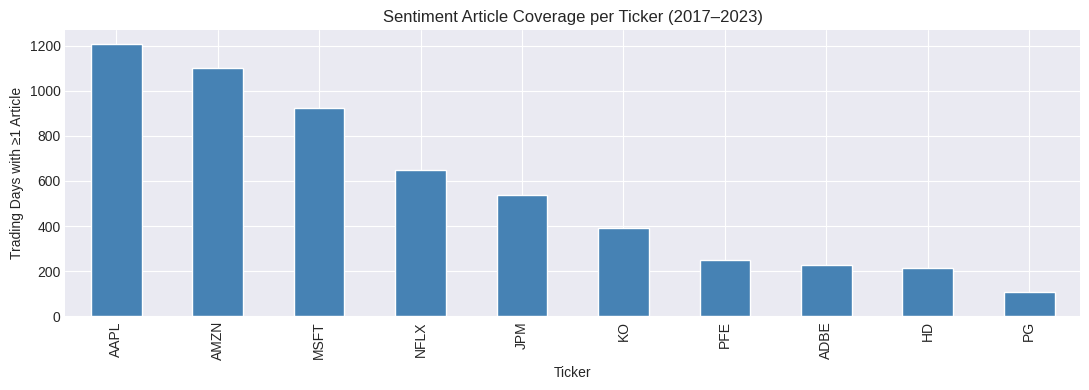

In [6]:
coverage = (
    sentiment_daily.reset_index()
    .groupby("ticker")["date"].count()
    .sort_values(ascending=False)
    .rename("article_days")
)
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
coverage.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Sentiment Article Coverage per Ticker (2017–2023)")
ax.set_xlabel("Ticker")
ax.set_ylabel("Trading Days with ≥1 Article")
plt.tight_layout()
plt.show()

## 3. Download & Engineer Macro Features

For each series defined in `MACRO_SERIES` the notebook computes:

| Derived feature | Description |
|---|---|
| `{prefix}_ret` | Daily log-return of the closing price |
| `{prefix}_vol` | 5-day rolling volatility of returns |
| `{prefix}_lvl` | Normalised level (useful for VIX, yields) |

All three columns are generated for every series. You can drop any of them by editing `MACRO_FEATURE_COLS` below after the cell runs.

In [7]:
def download_macro(series_list: list, start: str, end: str) -> pd.DataFrame:
    """
    Download macro series from Yahoo Finance and engineer ret / vol / lvl features.
    Returns a date-indexed DataFrame ready for merging with stock data.
    """
    frames = []
    for ticker, prefix in tqdm(series_list, desc="Macro download"):
        raw = yf.download(ticker, start=start, end=end,
                          progress=False, auto_adjust=True)
        if raw.empty:
            print(f"  WARNING: no data for {ticker} — skipping.")
            continue
        close = raw["Close"].squeeze()
        df = pd.DataFrame(index=close.index)
        df[f"{prefix}_ret"] = close.pct_change()
        df[f"{prefix}_vol"] = df[f"{prefix}_ret"].rolling(5).std()
        df[f"{prefix}_lvl"] = close                          # raw level (VIX, yields)
        frames.append(df)

    if not frames:
        raise RuntimeError("No macro data downloaded. Check tickers / internet access.")

    macro = pd.concat(frames, axis=1)
    macro.index.name = "date"
    macro = macro.reset_index()
    macro["date"] = pd.to_datetime(macro["date"]).dt.normalize()
    print(f"Macro features: {[c for c in macro.columns if c != 'date']}")
    return macro


macro_df = download_macro(MACRO_SERIES, start=PRICE_DOWNLOAD_START, end=TEST_END)

# ── Choose which macro columns to actually include as model features ───────────
# By default every column is included. Comment out any you want to exclude.
MACRO_FEATURE_COLS = [c for c in macro_df.columns if c != "date"]
print(f"\nMacro feature columns ({len(MACRO_FEATURE_COLS)}): {MACRO_FEATURE_COLS}")

Macro download: 100%|██████████| 4/4 [00:01<00:00,  3.45it/s]

Macro features: ['sp500_ret', 'sp500_vol', 'sp500_lvl', 'vix_ret', 'vix_vol', 'vix_lvl', 't10y_ret', 't10y_vol', 't10y_lvl', 'usd_ret', 'usd_vol', 'usd_lvl']

Macro feature columns (12): ['sp500_ret', 'sp500_vol', 'sp500_lvl', 'vix_ret', 'vix_vol', 'vix_lvl', 't10y_ret', 't10y_vol', 't10y_lvl', 'usd_ret', 'usd_vol', 'usd_lvl']


### 3a. Macro Feature Visualisation

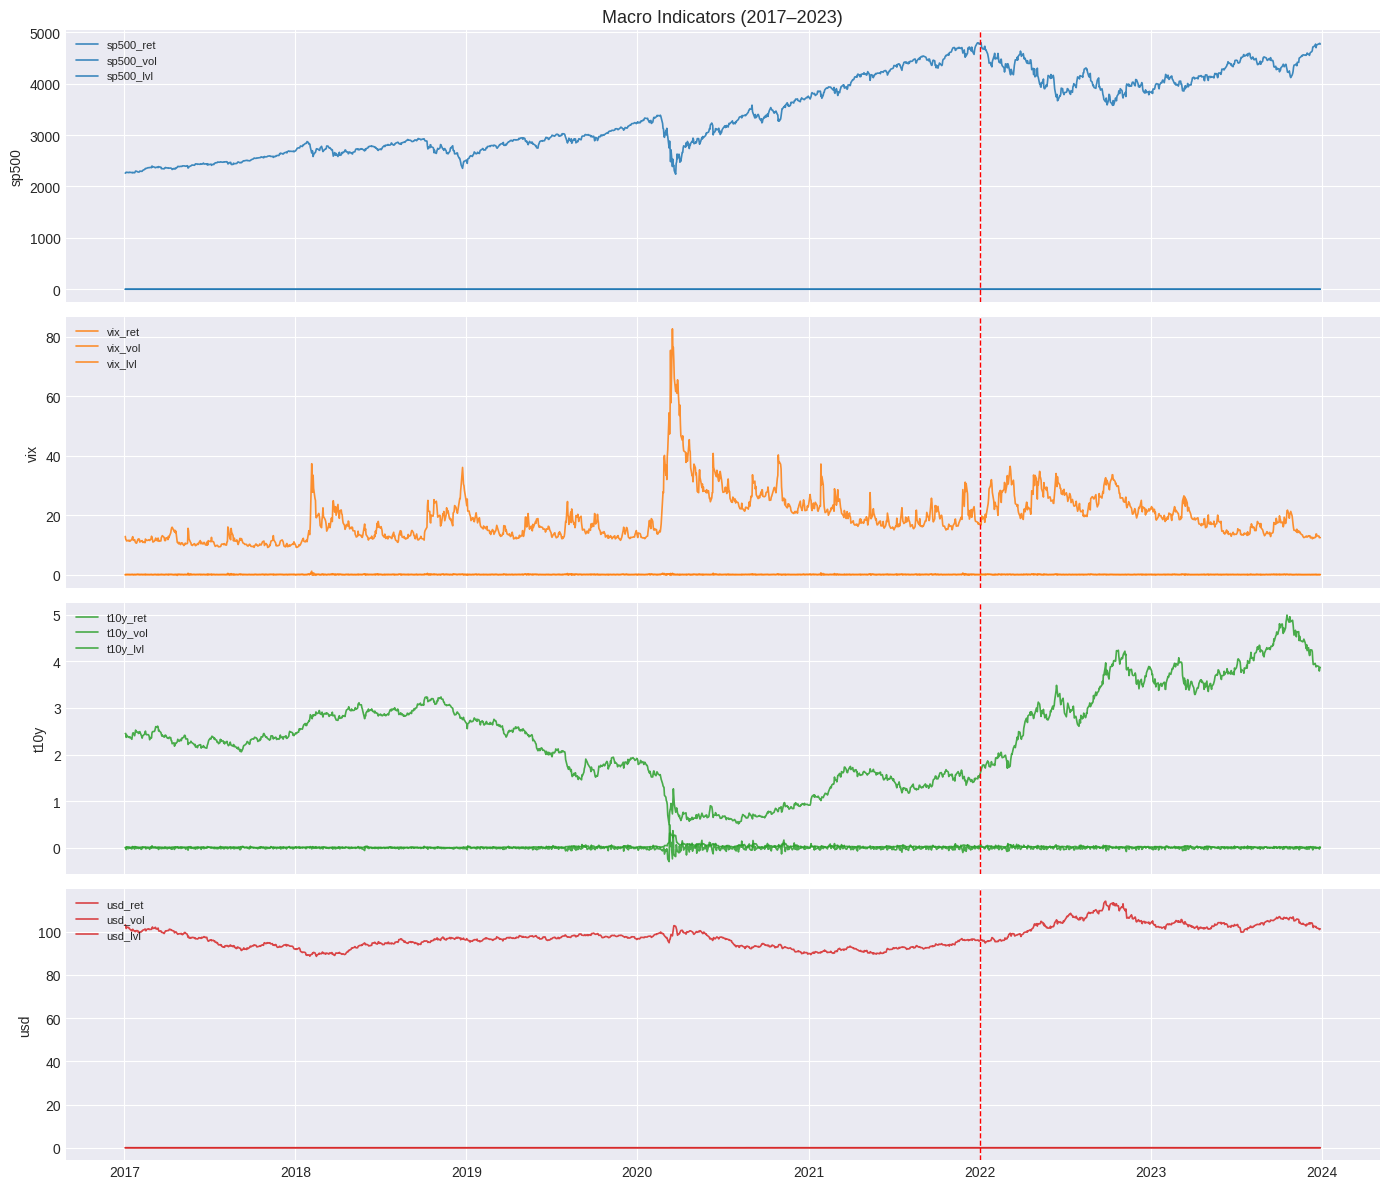

In [8]:
macro_plot = macro_df.set_index("date").loc[TRAIN_START:TEST_END]
prefixes   = list(dict.fromkeys(c.rsplit("_", 1)[0] for c in MACRO_FEATURE_COLS))
n          = len(prefixes)
fig, axes  = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

palette = plt.cm.tab10.colors
for ax, (pfx, color) in zip(axes, zip(prefixes, palette)):
    cols = [c for c in MACRO_FEATURE_COLS if c.startswith(pfx)]
    for col in cols:
        ax.plot(macro_plot.index, macro_plot[col], label=col, lw=1.2, color=color, alpha=0.85)
    ax.set_ylabel(pfx, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.axvline(pd.Timestamp(TEST_START), color="red", lw=1, linestyle="--", label="Test start")

axes[0].set_title("Macro Indicators (2017–2023)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Download Stock Prices & Engineer Technical Features

In [9]:
def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_stock_features(ticker: str, start: str, end: str) -> pd.DataFrame:
    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if raw.empty:
        return pd.DataFrame()
    close  = raw["Close"].squeeze()
    volume = raw["Volume"].squeeze()

    df = pd.DataFrame(index=raw.index)
    df["return"]     = close.pct_change()
    df["rsi"]        = compute_rsi(close, 14)
    df["volume"]     = volume
    df["volatility"] = df["return"].rolling(5).std()
    df["target"]     = df["return"].shift(-1)     # next-day return to predict
    df["ticker"]     = ticker
    return df.dropna(subset=["return", "rsi", "volatility"])


print("Downloading stock price data…")
price_frames = {}
for t in tqdm(SP500_TICKERS):
    price_frames[t] = compute_stock_features(t, PRICE_DOWNLOAD_START, TEST_END)

price_df = pd.concat(price_frames.values())
price_df.index.name = "date"
price_df = price_df.reset_index()
price_df["date"] = pd.to_datetime(price_df["date"]).dt.normalize()

# Restrict to the analysis window (sentiment coverage starts 2017)
price_df = price_df[price_df["date"] >= TRAIN_START]

print(f"Price data shape: {price_df.shape}")
price_df.head(3)

100%|██████████| 10/10 [00:03<00:00,  3.03it/s]

Price data shape: (17600, 7)


,date,return,rsi,volume,volatility,target,ticker
113,2017-01-03,0.002849,69.601494,115127600,0.005602,-0.001119,AAPL
114,2017-01-04,-0.001119,57.531893,84472400,0.004061,0.005085,AAPL
115,2017-01-05,0.005085,61.639511,88774400,0.004893,0.011148,AAPL


## 5. Merge All Feature Layers

Merge order: price → sentiment → macro.  
Gaps in sentiment are forward-filled (carry last known score), then set to neutral.  
Gaps in macro are forward-filled only (market holidays/weekends).

In [10]:
# ── 5a. Merge sentiment ────────────────────────────────────────────────────────
sent_reset = sentiment_daily.reset_index()
sent_reset["date"] = pd.to_datetime(sent_reset["date"]).dt.normalize()

merged = price_df.merge(sent_reset, on=["date", "ticker"], how="left")

SENTIMENT_COLS = [c for c in merged.columns if c.startswith("sent_") or c.startswith("emotion_")]
print(f"Sentiment columns ({len(SENTIMENT_COLS)}): {SENTIMENT_COLS}")

merged = merged.sort_values(["ticker", "date"])
merged[SENTIMENT_COLS] = (
    merged.groupby("ticker")[SENTIMENT_COLS]
    .transform(lambda x: x.ffill())
)
fill_defaults = {c: 0.0 for c in SENTIMENT_COLS}
if "sent_neutral" in fill_defaults:
    fill_defaults["sent_neutral"] = 1.0
if "emotion_neutral" in fill_defaults:
    fill_defaults["emotion_neutral"] = 1.0
merged[SENTIMENT_COLS] = merged[SENTIMENT_COLS].fillna(fill_defaults)

# ── 5b. Merge macro ───────────────────────────────────────────────────────────
merged = merged.merge(macro_df[["date"] + MACRO_FEATURE_COLS],
                      on="date", how="left")
merged[MACRO_FEATURE_COLS] = (
    merged[MACRO_FEATURE_COLS].ffill()
)
merged[MACRO_FEATURE_COLS] = merged[MACRO_FEATURE_COLS].fillna(0.0)

# ── 5c. Define feature sets ───────────────────────────────────────────────────
BASE_FEATURES      = ["return", "rsi", "volume", "volatility"]
SENT_FEATURES      = BASE_FEATURES + SENTIMENT_COLS
MACRO_FEATURES     = BASE_FEATURES + MACRO_FEATURE_COLS
FULL_FEATURES      = BASE_FEATURES + SENTIMENT_COLS + MACRO_FEATURE_COLS

print(f"\nFeature set sizes:")
print(f"  Base              : {len(BASE_FEATURES)}")
print(f"  Base + Sentiment  : {len(SENT_FEATURES)}")
print(f"  Base + Macro      : {len(MACRO_FEATURES)}")
print(f"  Base + Sent + Macro: {len(FULL_FEATURES)}")

Sentiment columns (10): ['sent_negative', 'sent_neutral', 'sent_positive', 'emotion_neutral', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_sadness', 'emotion_joy', 'emotion_fear']

Feature set sizes:
  Base              : 4
  Base + Sentiment  : 14
  Base + Macro      : 16
  Base + Sent + Macro: 26


### 5a. Sentiment Distribution

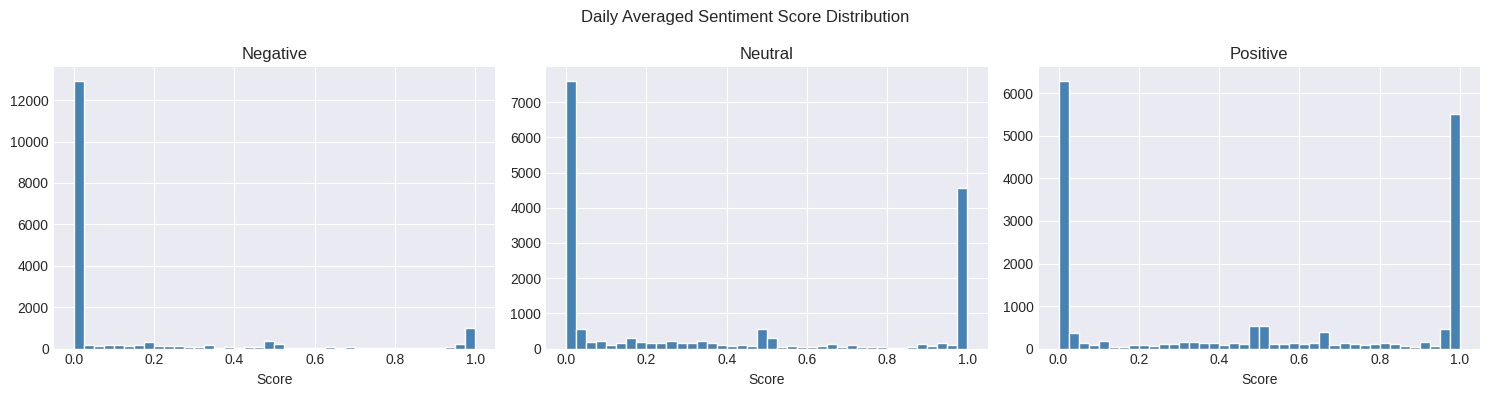

In [11]:
core_sent = [c for c in ["sent_negative", "sent_neutral", "sent_positive"] if c in merged.columns]
if core_sent:
    fig, axes = plt.subplots(1, len(core_sent), figsize=(5 * len(core_sent), 4))
    if len(core_sent) == 1:
        axes = [axes]
    for ax, col in zip(axes, core_sent):
        ax.hist(merged[col].dropna(), bins=40, color="steelblue", edgecolor="white")
        ax.set_title(col.replace("sent_", "").capitalize())
        ax.set_xlabel("Score")
    plt.suptitle("Daily Averaged Sentiment Score Distribution", fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Dataset Builder

In [12]:
def build_dataset(
    df: pd.DataFrame,
    tickers: list,
    feature_cols: list,
    lookback: int  = LOOKBACK,
    train_end: str = TRAIN_END,
    test_start: str = TEST_START,
):
    """
    Sliding-window dataset builder.
    Returns (X_train, y_train, X_test, y_test, scaler, test_meta_df).
    Scaler is fitted on training data only to prevent look-ahead bias.
    """
    sub = df[df["ticker"].isin(tickers)].copy()
    sub = sub.dropna(subset=feature_cols + ["target"])
    sub = sub.sort_values(["ticker", "date"])

    train_end_dt  = pd.Timestamp(train_end)
    test_start_dt = pd.Timestamp(test_start)

    train_data = sub[sub["date"] <= train_end_dt]
    scaler = StandardScaler()
    scaler.fit(train_data[feature_cols])

    X_train, y_train, X_test, y_test, test_meta = [], [], [], [], []

    for ticker, grp in sub.groupby("ticker"):
        grp    = grp.reset_index(drop=True)
        scaled  = scaler.transform(grp[feature_cols])
        targets = grp["target"].values
        dates   = grp["date"].values

        for i in range(lookback, len(grp)):
            window = scaled[i - lookback: i]
            target = targets[i]
            date   = dates[i]

            if np.isnan(target) or np.any(np.isnan(window)):
                continue

            if pd.Timestamp(date) <= train_end_dt:
                X_train.append(window)
                y_train.append(target)
            elif pd.Timestamp(date) >= test_start_dt:
                X_test.append(window)
                y_test.append(target)
                test_meta.append({"date": pd.Timestamp(date), "ticker": ticker})

    arrs = [np.array(a, dtype=np.float32)
            for a in (X_train, y_train, X_test, y_test)]
    print(f"  Train {arrs[0].shape}  Test {arrs[2].shape}")
    return (*arrs, scaler, pd.DataFrame(test_meta))


print("Building datasets…")
print(" [1/4] Base (technical only)")
ds_base  = build_dataset(merged, SP500_TICKERS, BASE_FEATURES)
print(" [2/4] Base + Sentiment")
ds_sent  = build_dataset(merged, SP500_TICKERS, SENT_FEATURES)
print(" [3/4] Base + Macro")
ds_macro = build_dataset(merged, SP500_TICKERS, MACRO_FEATURES)
print(" [4/4] Base + Sentiment + Macro (full)")
ds_full  = build_dataset(merged, SP500_TICKERS, FULL_FEATURES)

Building datasets…
 [1/4] Base (technical only)
  Train (12490, 10, 4)  Test (5000, 10, 4)
 [2/4] Base + Sentiment
  Train (12490, 10, 14)  Test (5000, 10, 14)
 [3/4] Base + Macro
  Train (12490, 10, 16)  Test (5000, 10, 16)
 [4/4] Base + Sentiment + Macro (full)
  Train (12490, 10, 26)  Test (5000, 10, 26)


## 7. Model Definitions

In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        flat = input_dim[0] * input_dim[1]
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat,       hidden * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),     nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class CNN(nn.Module):
    def __init__(self, input_dim, hidden=HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        n_feat = input_dim[1]
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat, hidden, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    def forward(self, x):           # x: (B, L, F)
        return self.fc(self.conv(x.permute(0, 2, 1)).squeeze(-1)).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=HIDDEN_SIZE, dropout=DROPOUT, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim[1], hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden=HIDDEN_SIZE, dropout=DROPOUT,
                 nhead=4, num_layers=2):
        super().__init__()
        self.embed = nn.Linear(input_dim[1], hidden)
        enc_layer  = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=nhead, dropout=dropout,
            dim_feedforward=hidden * 4, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc      = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)


MODEL_CLASSES = {
    "MLP":         MLP,
    "CNN":         CNN,
    "LSTM":        LSTMModel,
    "Transformer": TransformerModel,
}
print("Models:", list(MODEL_CLASSES.keys()))

Models: ['MLP', 'CNN', 'LSTM', 'Transformer']


## 8. Training & Inference

In [14]:
def train_model(model_cls, X_train, y_train, input_dim,
                epochs=EPOCHS, lr=LEARNING_RATE,
                batch_size=BATCH_SIZE, verbose=False):
    model     = model_cls(input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    dl = DataLoader(
        TensorDataset(torch.tensor(X_train).to(DEVICE),
                      torch.tensor(y_train).to(DEVICE)),
        batch_size=batch_size, shuffle=True
    )
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(dl.dataset)
        losses.append(epoch_loss)
        scheduler.step(epoch_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}/{epochs}  loss={epoch_loss:.6f}")
    return model, losses


def predict(model, X_test):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X_test).to(DEVICE)).cpu().numpy()


print("Training utilities ready.")

Training utilities ready.


## 9. Portfolio Metrics

In [15]:
def long_short_portfolio_returns(
    predictions: np.ndarray,
    actual_returns: np.ndarray,
    meta_df: pd.DataFrame
) -> pd.Series:
    """
    Equal-weight long-short strategy.
    Long stocks with pred > 0, short stocks with pred < 0.
    """
    df = meta_df.copy()
    df["pred"]   = predictions
    df["actual"] = actual_returns

    rows = []
    for date, grp in df.groupby("date"):
        longs  = grp[grp["pred"] > 0]
        shorts = grp[grp["pred"] < 0]
        n = len(longs) + len(shorts)
        if n == 0:
            rows.append({"date": date, "return": 0.0})
            continue
        w = 1.0 / n
        rows.append({"date": date,
                     "return": w * longs["actual"].sum() - w * shorts["actual"].sum()})

    return pd.DataFrame(rows).set_index("date")["return"].sort_index()


def portfolio_metrics(returns: pd.Series, rf: float = 0.0) -> dict:
    total  = (1 + returns).prod() - 1
    excess = returns - rf / 252
    sharpe = (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else 0.0
    cum    = (1 + returns).cumprod()
    max_dd = abs(((cum - cum.cummax()) / cum.cummax()).min())
    return {
        "Total Return": round(total,  6),
        "Sharpe Ratio": round(sharpe, 6),
        "Max Drawdown": round(max_dd, 6),
    }


print("Portfolio metric utilities ready.")

Portfolio metric utilities ready.


## 10. Experiment Runner

In [16]:
def run_experiment(label: str, dataset: tuple) -> tuple:
    X_tr, y_tr, X_te, y_te, _, meta = dataset
    input_dim = (X_tr.shape[1], X_tr.shape[2])
    results, port_rets = {}, {}

    for name, cls in MODEL_CLASSES.items():
        print(f"  [{label}] {name}…")
        model, _  = train_model(cls, X_tr, y_tr, input_dim)
        preds     = predict(model, X_te)
        port_ret  = long_short_portfolio_returns(preds, y_te, meta)
        m         = portfolio_metrics(port_ret)
        results[name]   = m
        port_rets[name] = port_ret
        print(f"    Return={m['Total Return']:+.4f}  "
              f"Sharpe={m['Sharpe Ratio']:.4f}  "
              f"MaxDD={m['Max Drawdown']:.4f}")

    return results, port_rets


print("=" * 60 + "\nS&P 500 — Technical baseline")
res_base,  rets_base  = run_experiment("Base",  ds_base)

print("\n" + "=" * 60 + "\nS&P 500 — + Sentiment")
res_sent,  rets_sent  = run_experiment("Sent",  ds_sent)

print("\n" + "=" * 60 + "\nS&P 500 — + Macro")
res_macro, rets_macro = run_experiment("Macro", ds_macro)

print("\n" + "=" * 60 + "\nS&P 500 — + Sentiment + Macro (full)")
res_full,  rets_full  = run_experiment("Full",  ds_full)

S&P 500 — Technical baseline
  [Base] MLP…
    Return=-0.1081  Sharpe=-0.2453  MaxDD=0.3189
  [Base] CNN…
    Return=+0.1085  Sharpe=0.3608  MaxDD=0.2223
  [Base] LSTM…
    Return=+0.0713  Sharpe=0.3016  MaxDD=0.1757
  [Base] Transformer…
    Return=+0.1025  Sharpe=0.3837  MaxDD=0.1928

S&P 500 — + Sentiment
  [Sent] MLP…
    Return=+0.0971  Sharpe=0.3494  MaxDD=0.2083
  [Sent] CNN…
    Return=+0.0188  Sharpe=0.1416  MaxDD=0.2732
  [Sent] LSTM…
    Return=+0.0494  Sharpe=0.2418  MaxDD=0.2117
  [Sent] Transformer…
    Return=+0.3017  Sharpe=0.9556  MaxDD=0.2250

S&P 500 — + Macro
  [Macro] MLP…
    Return=+0.0044  Sharpe=0.1048  MaxDD=0.2143
  [Macro] CNN…
    Return=+0.0583  Sharpe=0.2460  MaxDD=0.2944
  [Macro] LSTM…
    Return=-0.0414  Sharpe=-0.0185  MaxDD=0.2620
  [Macro] Transformer…
    Return=-0.2407  Sharpe=-0.6308  MaxDD=0.3072

S&P 500 — + Sentiment + Macro (full)
  [Full] MLP…
    Return=-0.3591  Sharpe=-1.3064  MaxDD=0.4392
  [Full] CNN…
    Return=+0.1196  Sharpe=0.4072  M

## 11. Results Tables

In [17]:
def multi_comparison_table(result_dict: dict) -> pd.DataFrame:
    """
    Build a tidy multi-index DataFrame.
    result_dict: {label: {model: {metric: value}}}
    """
    rows = []
    for label, model_dict in result_dict.items():
        for model, metrics in model_dict.items():
            rows.append({"Feature Set": label, "Model": model, **metrics})
    df = pd.DataFrame(rows).set_index(["Feature Set", "Model"])
    return df


all_results = {
    "Base (technical)": res_base,
    "+ Sentiment":      res_sent,
    "+ Macro":          res_macro,
    "+ Sent + Macro":   res_full,
}

comparison_df = multi_comparison_table(all_results)
print("\nFull comparison table:")
print(comparison_df.to_string())
comparison_df


Full comparison table:
                              Total Return  Sharpe Ratio  Max Drawdown
Feature Set      Model                                                
Base (technical) MLP             -0.108073     -0.245338      0.318940
                 CNN              0.108489      0.360754      0.222280
                 LSTM             0.071299      0.301608      0.175672
                 Transformer      0.102492      0.383747      0.192765
+ Sentiment      MLP              0.097097      0.349367      0.208292
                 CNN              0.018807      0.141592      0.273194
                 LSTM             0.049385      0.241828      0.211672
                 Transformer      0.301717      0.955627      0.225028
+ Macro          MLP              0.004352      0.104755      0.214303
                 CNN              0.058314      0.246048      0.294396
                 LSTM            -0.041428     -0.018492      0.261979
                 Transformer     -0.240698     -0.630

Total Return  Sharpe Ratio  Max Drawdown
Feature Set      Model                                                
Base (technical) MLP             -0.108073     -0.245338      0.318940
                 CNN              0.108489      0.360754      0.222280
                 LSTM             0.071299      0.301608      0.175672
                 Transformer      0.102492      0.383747      0.192765
+ Sentiment      MLP              0.097097      0.349367      0.208292
                 CNN              0.018807      0.141592      0.273194
                 LSTM             0.049385      0.241828      0.211672
                 Transformer      0.301717      0.955627      0.225028
+ Macro          MLP              0.004352      0.104755      0.214303
                 CNN              0.058314      0.246048      0.294396
                 LSTM            -0.041428     -0.018492      0.261979
                 Transformer     -0.240698     -0.630818      0.307199
+ Sent + Macro   MLP             -0.359093     -1.306358      0.439172
                 CNN              0.119553      0.407242      0.183339
                 LSTM            -0.159143     -0.444975      0.200155
                 Transformer     -0.126731     -0.272145      0.223417

## 12. Visualisations

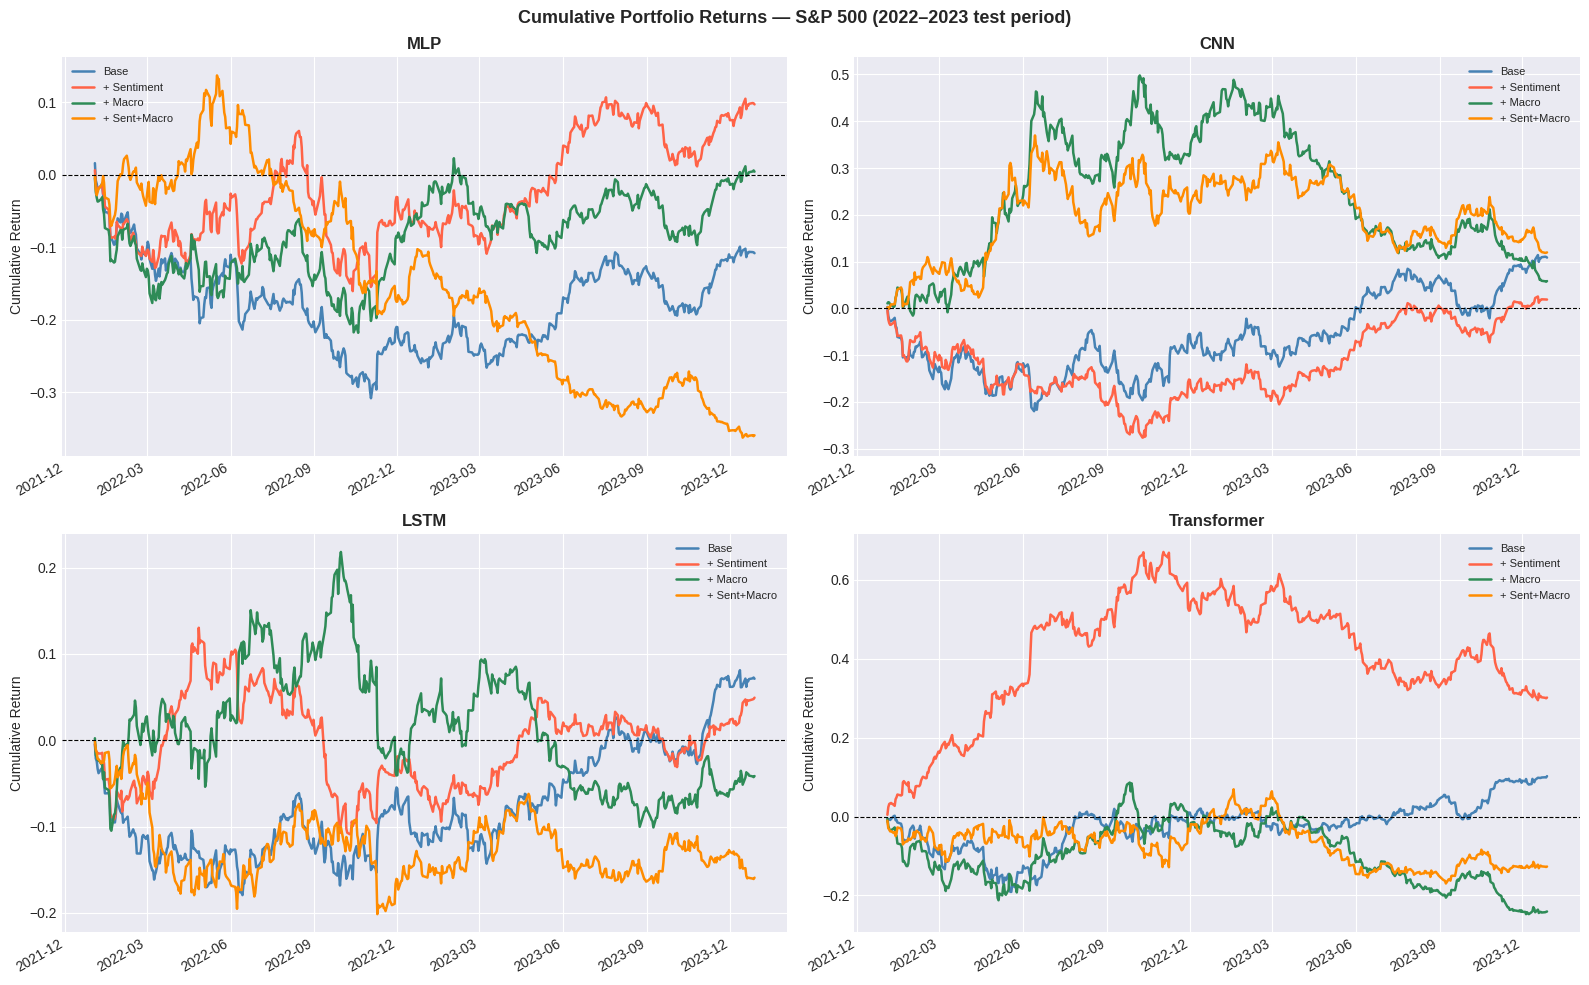

In [18]:
# ── 12a. Cumulative returns: one subplot per model, four lines per subplot ─────
rets_sets = {
    "Base":          rets_base,
    "+ Sentiment":   rets_sent,
    "+ Macro":       rets_macro,
    "+ Sent+Macro":  rets_full,
}
line_colors = ["steelblue", "tomato", "seagreen", "darkorange"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, model in zip(axes, MODEL_CLASSES.keys()):
    for (label, rets_dict), color in zip(rets_sets.items(), line_colors):
        cum = (1 + rets_dict[model]).cumprod() - 1
        ax.plot(cum.index, cum.values, label=label, color=color, lw=1.8)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_ylabel("Cumulative Return")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.legend(fontsize=8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")

plt.suptitle("Cumulative Portfolio Returns — S&P 500 (2022–2023 test period)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

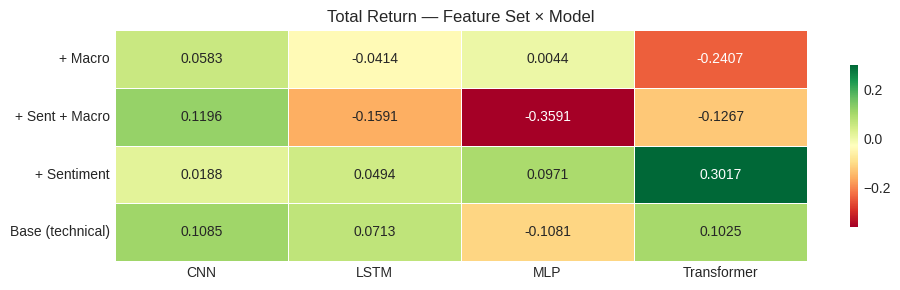

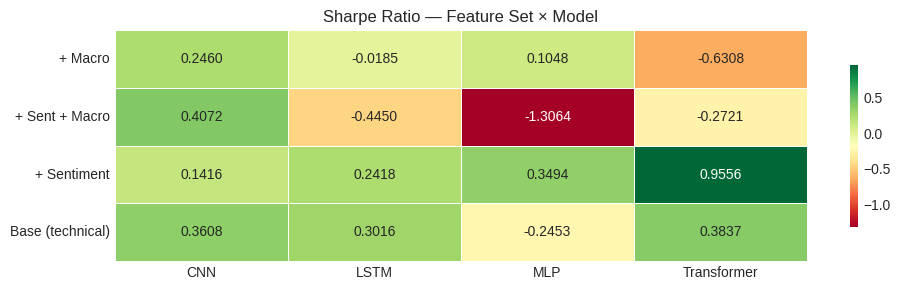

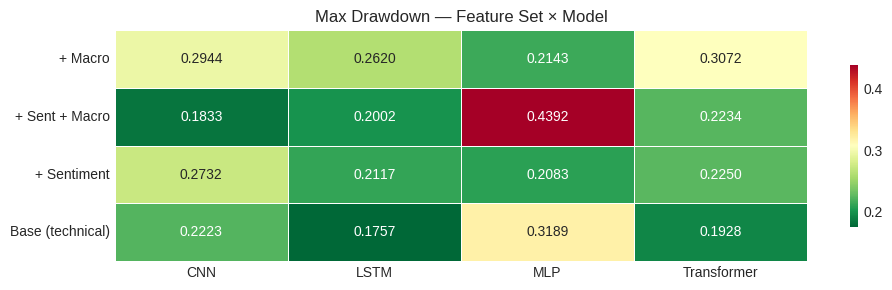

In [19]:
# ── 12b. Metric heatmap across feature sets × models ──────────────────────────
for metric in ["Total Return", "Sharpe Ratio", "Max Drawdown"]:
    pivot = comparison_df[metric].unstack(level="Model")
    fig, ax = plt.subplots(figsize=(10, 3))
    cmap = "RdYlGn" if metric != "Max Drawdown" else "RdYlGn_r"
    sns.heatmap(
        pivot, annot=True, fmt=".4f", cmap=cmap,
        ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.7}
    )
    ax.set_title(f"{metric} — Feature Set × Model", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

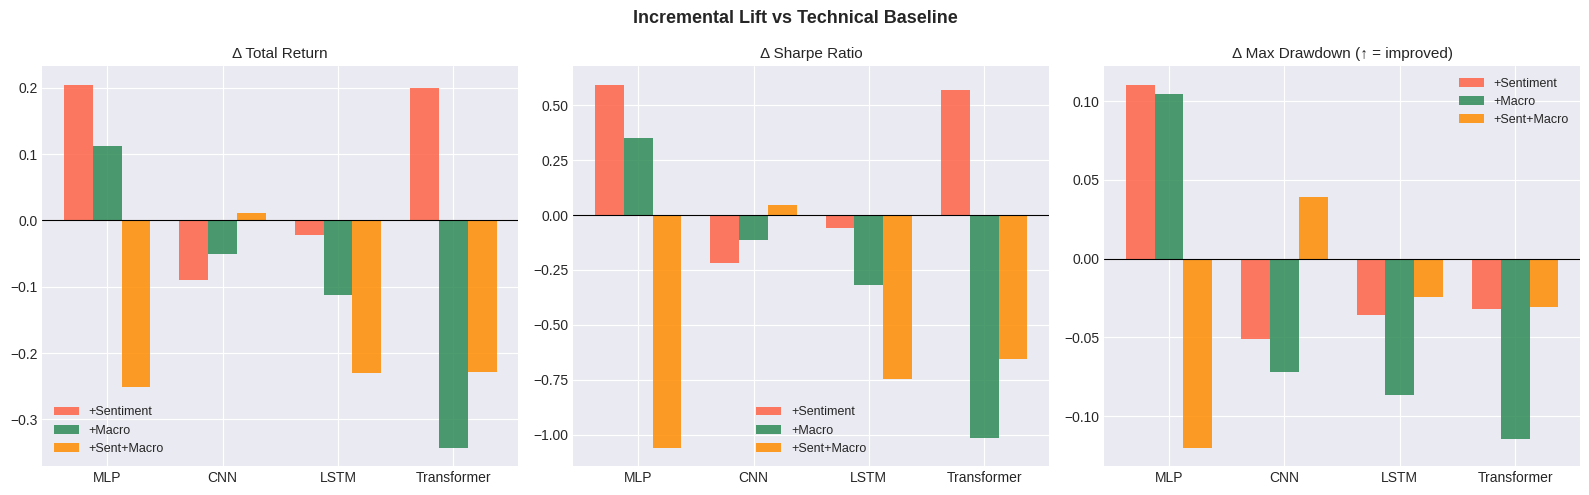

In [20]:
# ── 12c. Incremental lift bar chart (vs technical baseline) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["Total Return", "Sharpe Ratio", "Max Drawdown"]
augmented_labels = ["+Sentiment", "+Macro", "+Sent+Macro"]
aug_res_list     = [res_sent, res_macro, res_full]
bar_colors       = ["tomato", "seagreen", "darkorange"]

for ax, metric in zip(axes, metrics_to_plot):
    x     = np.arange(len(MODEL_CLASSES))
    width = 0.25
    for i, (aug_label, aug_res, color) in enumerate(
            zip(augmented_labels, aug_res_list, bar_colors)):
        deltas = [
            aug_res[m][metric] - res_base[m][metric]
            for m in MODEL_CLASSES
        ]
        # For max drawdown, lower is better so we flip sign for display
        if metric == "Max Drawdown":
            deltas = [-d for d in deltas]
        ax.bar(x + i * width, deltas, width, label=aug_label, color=color, alpha=0.85)

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(list(MODEL_CLASSES.keys()))
    title = metric if metric != "Max Drawdown" else "Max Drawdown (↑ = improved)"
    ax.set_title(f"Δ {title}", fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Incremental Lift vs Technical Baseline",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Ablation Study

Tests four feature subsets to isolate the contribution of each layer:  
`Technical only` | `Sentiment only` | `Macro only` | `All combined`

In [21]:
ABLATION_SETS = {
    "Technical only":  BASE_FEATURES,
    "Sentiment only":  SENTIMENT_COLS,
    "Macro only":      MACRO_FEATURE_COLS,
    "All combined":    FULL_FEATURES,
}

ablation_rows = []
for fs_name, feats in ABLATION_SETS.items():
    if not feats:
        print(f"  Skipping '{fs_name}' — no features available.")
        continue
    print(f"\n  Ablation — {fs_name} ({len(feats)} features)")
    ds = build_dataset(merged, SP500_TICKERS, feats)
    X_tr, y_tr, X_te, y_te, _, meta = ds
    input_dim = (X_tr.shape[1], X_tr.shape[2])

    for name, cls in MODEL_CLASSES.items():
        model, _ = train_model(cls, X_tr, y_tr, input_dim)
        preds    = predict(model, X_te)
        port_ret = long_short_portfolio_returns(preds, y_te, meta)
        m        = portfolio_metrics(port_ret)
        ablation_rows.append({
            "Feature Set": fs_name, "Model": name,
            **m
        })
        print(f"    {name:12s} Sharpe={m['Sharpe Ratio']:.4f}")

ablation_df = pd.DataFrame(ablation_rows).set_index(["Feature Set", "Model"])
print("\nAblation results:")
ablation_df


  Ablation — Technical only (4 features)
  Train (12490, 10, 4)  Test (5000, 10, 4)
    MLP          Sharpe=0.1186
    CNN          Sharpe=0.1024
    LSTM         Sharpe=0.4517
    Transformer  Sharpe=0.5894

  Ablation — Sentiment only (10 features)
  Train (12490, 10, 10)  Test (5000, 10, 10)
    MLP          Sharpe=0.0436
    CNN          Sharpe=0.1024
    LSTM         Sharpe=-0.0117
    Transformer  Sharpe=-0.1051

  Ablation — Macro only (12 features)
  Train (12490, 10, 12)  Test (5000, 10, 12)
    MLP          Sharpe=0.3346
    CNN          Sharpe=1.0909
    LSTM         Sharpe=1.3132
    Transformer  Sharpe=0.0836

  Ablation — All combined (26 features)
  Train (12490, 10, 26)  Test (5000, 10, 26)
    MLP          Sharpe=0.0613
    CNN          Sharpe=0.7495
    LSTM         Sharpe=-0.9916
    Transformer  Sharpe=0.0330

Ablation results:


Total Return  Sharpe Ratio  Max Drawdown
Feature Set    Model                                                
Technical only MLP              0.011091      0.118569      0.245525
               CNN             -0.002579      0.102427      0.312889
               LSTM             0.107860      0.451741      0.170075
               Transformer      0.155077      0.589415      0.167004
Sentiment only MLP             -0.021702      0.043573      0.296018
               CNN             -0.002579      0.102427      0.312889
               LSTM            -0.040928     -0.011689      0.294910
               Transformer     -0.086537     -0.105136      0.338989
Macro only     MLP              0.102322      0.334580      0.246120
               CNN              0.524960      1.090861      0.195917
               LSTM             0.676858      1.313184      0.185428
               Transformer     -0.010497      0.083581      0.281689
All combined   MLP             -0.005657      0.061345      0.217341
               CNN              0.258628      0.749460      0.171968
               LSTM            -0.313713     -0.991564      0.335593
               Transformer     -0.020782      0.033040      0.216892

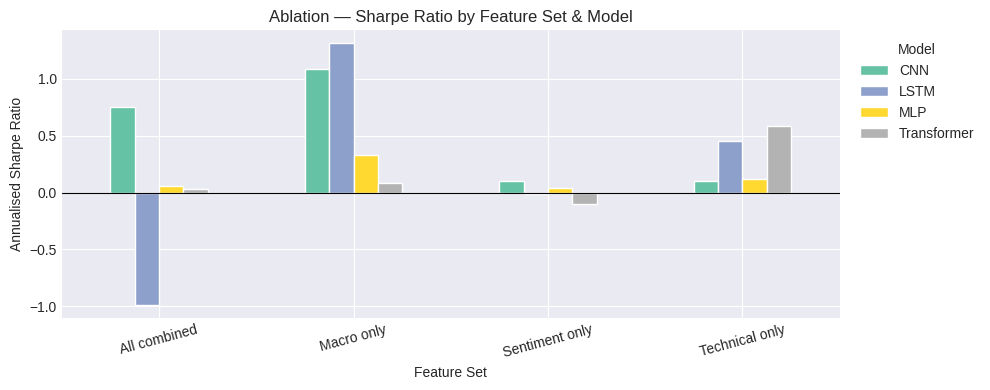

In [22]:
sharpe_pivot = ablation_df["Sharpe Ratio"].unstack(level="Model")
fig, ax = plt.subplots(figsize=(10, 4))
sharpe_pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Ablation — Sharpe Ratio by Feature Set & Model", fontsize=12)
ax.set_ylabel("Annualised Sharpe Ratio")
ax.set_xlabel("Feature Set")
plt.xticks(rotation=15)
plt.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 14. Summary

In [23]:
print("\n" + "#" * 70)
print("  FINAL SUMMARY — S&P 500, 2022–2023 test period")
print("#" * 70)

compare_pairs = [
    ("+Sentiment vs Base",    res_sent,  res_base),
    ("+Macro vs Base",        res_macro, res_base),
    ("+Sent+Macro vs Base",   res_full,  res_base),
]

for label, aug, base in compare_pairs:
    print(f"\n  {label}")
    print(f"  {'─'*45}")
    for metric in ["Total Return", "Sharpe Ratio", "Max Drawdown"]:
        deltas = [aug[m][metric] - base[m][metric] for m in MODEL_CLASSES]
        sign   = -1 if metric == "Max Drawdown" else 1
        n_improved = sum(sign * d > 0 for d in deltas)
        avg_delta  = np.mean(deltas)
        print(f"    {metric:18s}  improved: {n_improved}/{len(MODEL_CLASSES)}  "
              f"avg Δ={avg_delta:+.4f}")

print("\n  Best single configuration (Sharpe Ratio):")
best = comparison_df["Sharpe Ratio"].idxmax()
print(f"    Feature Set='{best[0]}'  Model='{best[1]}'  "
      f"Sharpe={comparison_df.loc[best, 'Sharpe Ratio']:.4f}")
print("\nDone.")


######################################################################
  FINAL SUMMARY — S&P 500, 2022–2023 test period
######################################################################

  +Sentiment vs Base
  ─────────────────────────────────────────────
    Total Return        improved: 2/4  avg Δ=+0.0732
    Sharpe Ratio        improved: 2/4  avg Δ=+0.2219
    Max Drawdown        improved: 1/4  avg Δ=+0.0021

  +Macro vs Base
  ─────────────────────────────────────────────
    Total Return        improved: 1/4  avg Δ=-0.0984
    Sharpe Ratio        improved: 1/4  avg Δ=-0.2748
    Max Drawdown        improved: 1/4  avg Δ=+0.0421

  +Sent+Macro vs Base
  ─────────────────────────────────────────────
    Total Return        improved: 1/4  avg Δ=-0.1749
    Sharpe Ratio        improved: 1/4  avg Δ=-0.6043
    Max Drawdown        improved: 1/4  avg Δ=+0.0341

  Best single configuration (Sharpe Ratio):
    Feature Set='+ Sentiment'  Model='Transformer'  Sharpe=0.9556

Done.
